In [4]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/utils/')
sys.path.append('../../../src/benchmark/')
from build_model import resnet50_
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


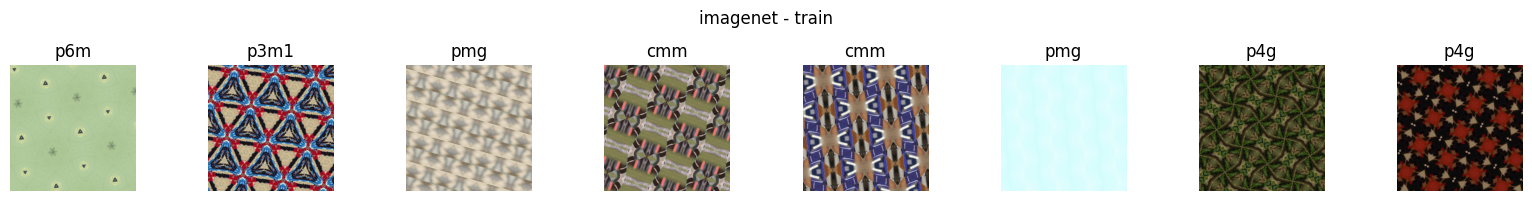

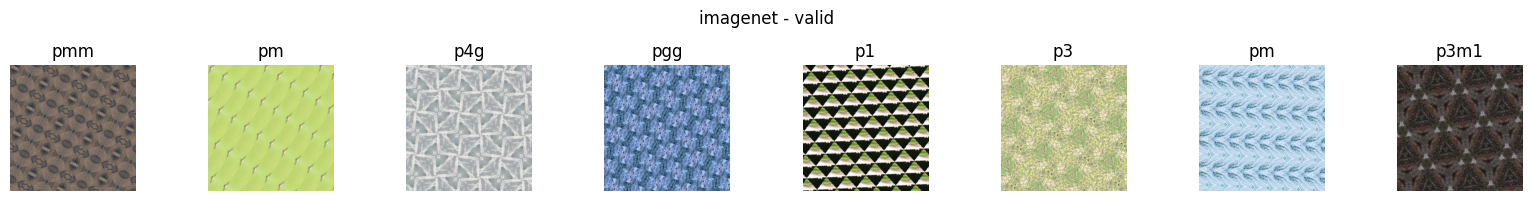

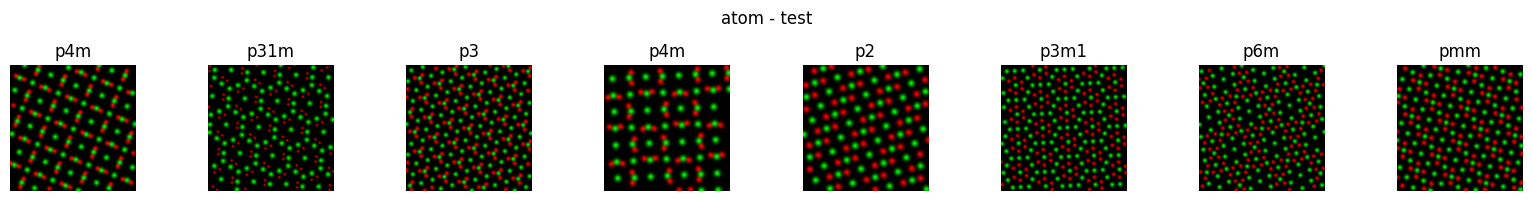

In [5]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test')

In [7]:
model = resnet50_(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


# train

In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'model': 'resnet50_yichen',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'Train_ImageNet-CrossValidate_Atom'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [01:47<00:00,  1.25it/s]


Training: Loss: 3.0460, Accuracy: 6.0688%, Time: 1.7849mins


100%|██████████| 34/34 [00:12<00:00,  2.81it/s]


...

Training: Loss: 0.0032, Accuracy: 99.9725%, Time: 1.7855mins


100%|██████████| 34/34 [00:12<00:00,  2.72it/s]


Validation : Loss : 0.3922, Accuracy: 92.2900%, Time: 0.21mins


100%|██████████| 167/167 [00:57<00:00,  2.91it/s]


Validation : Loss : 6.7245, Accuracy: 35.1700%, Time: 0.96mins


# analyze

In [6]:
from analysis_functions import confusion_matrix, plot_cm

ModuleNotFoundError: No module named 'analysis_functions'

In [ ]:
# model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

# NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
# symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
#                     'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [ ]:
# device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-train_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:48<00:00,  2.76it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4632.0,4725.0,4698.0,4719.0,4686.0,4661.0,4739.0,4679.0,4694.0,4711.0,4724.0,4654.0,4725.0,4728.0,4763.0,4756.0,4706.0


Accuracy for these batches: 0.9999875


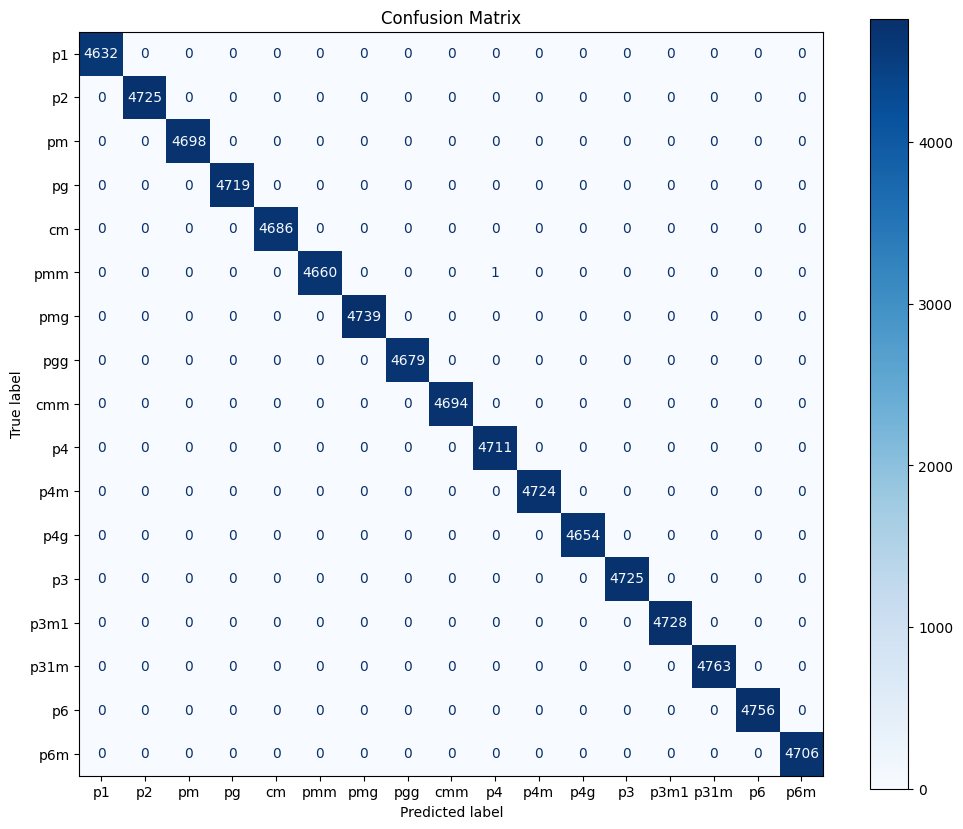

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, title=None, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-valid_cm.npy', cm)

  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:12<00:00,  2.78it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,1249.0,1161.0,1184.0,1160.0,1195.0,1217.0,1142.0,1204.0,1191.0,1170.0,1158.0,1229.0,1157.0,1156.0,1117.0,1130.0,1180.0


Accuracy for these batches: 0.97765


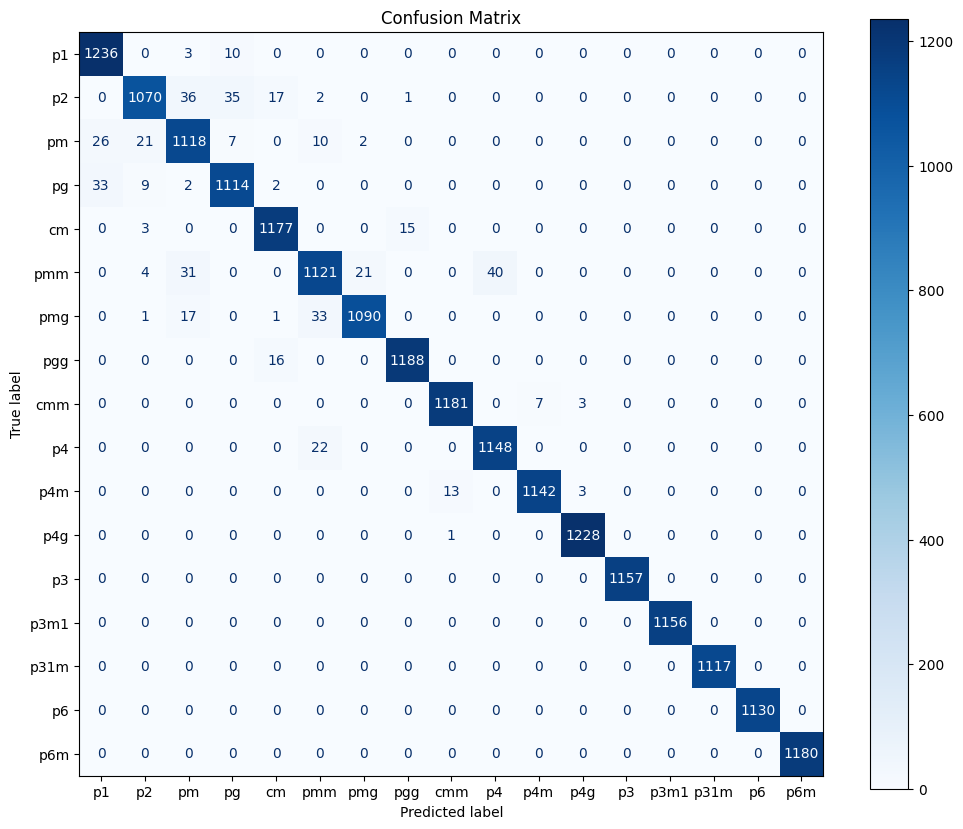

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-test_cm.npy', cm)

NameError: name 'confusion_matrix' is not defined

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

NameError: name 'plot_cm' is not defined